# Multivariate Forecasting: VAR and VARX

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from statsmodels.tsa.api import VAR


# Identify the repository root
current_dir = Path.cwd()

if (
    current_dir
    / "data"
    / "processed"
    / "water_climate_10_lakes_primary.csv"
).exists():

    PROJECT_ROOT = current_dir

elif (
    current_dir.parent
    / "data"
    / "processed"
    / "water_climate_10_lakes_primary.csv"
).exists():

    PROJECT_ROOT = current_dir.parent

else:
    raise FileNotFoundError(
        "Repository root could not be identified. "
        "Run this notebook from the repository root "
        "or from the notebooks directory."
    )

processed_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

outputs_path = (
    PROJECT_ROOT
    / "outputs"
)

forecast_output_dir = (
    outputs_path
    / "forecasting_results"
)

forecast_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# Load the locked primary dataset exported from Notebook 01
primary_data_file = (
    processed_path
    / "water_climate_10_lakes_primary.csv"
)

primary_water_climate = pd.read_csv(
    primary_data_file,
    parse_dates=["Date"]
)


lake_order = [
    "Lake Superior",
    "Lake Huron",
    "Lake Michigan",
    "Lake Erie",
    "Lake Ontario",
    "Lake Woods",
    "Great Salt Lake",
    "Lake Tahoe",
    "Red Lake",
    "Lake Champlain"
]


print(
    "Primary dataset shape:",
    primary_water_climate.shape
)

print(
    "Date range:",
    primary_water_climate["Date"].min(),
    "to",
    primary_water_climate["Date"].max()
)

Primary dataset shape: (73050, 8)
Date range: 2006-01-01 00:00:00 to 2025-12-31 00:00:00


In [2]:
# Construct and validate the locked primary water-level matrix
# used as the source for modelling and forecast evaluation

primary_lake_level_wide = (
    primary_water_climate
    .pivot(
        index="Date",
        columns="Lake",
        values="Lake_Level_ft"
    )
    .sort_index()
    .reindex(
        columns=lake_order
    )
    .asfreq("D")
)


# Expected retained long-gap missing values
# from the locked ERP-1 primary dataset

expected_primary_missing = {
    "Lake Superior": 31,
    "Lake Huron": 30,
    "Lake Michigan": 0,
    "Lake Erie": 0,
    "Lake Ontario": 30,
    "Lake Woods": 21,
    "Great Salt Lake": 0,
    "Lake Tahoe": 0,
    "Red Lake": 167,
    "Lake Champlain": 0
}


observed_primary_missing = (
    primary_lake_level_wide
    .isna()
    .sum()
    .astype(int)
    .to_dict()
)


if (
    observed_primary_missing
    != expected_primary_missing
):
    raise ValueError(
        "Primary evaluation dataset does not match "
        "the locked ERP-1 water-level series. "
        f"Observed missing counts: "
        f"{observed_primary_missing}"
    )


if len(
    primary_lake_level_wide
) != 7305:
    raise ValueError(
        "Expected 7,305 daily observations."
    )


if (
    primary_lake_level_wide.index.min()
    != pd.Timestamp("2006-01-01")
    or
    primary_lake_level_wide.index.max()
    != pd.Timestamp("2025-12-31")
):
    raise ValueError(
        "Primary evaluation dataset has "
        "an unexpected date range."
    )


print(
    "Primary evaluation dataset QC passed."
)

print(
    "Primary water-level missing values:"
)

display(
    primary_lake_level_wide
    .isna()
    .sum()
)

Primary evaluation dataset QC passed.
Primary water-level missing values:


Lake
Lake Superior       31
Lake Huron          30
Lake Michigan        0
Lake Erie            0
Lake Ontario        30
Lake Woods          21
Great Salt Lake      0
Lake Tahoe           0
Red Lake           167
Lake Champlain       0
dtype: int64

## VAR

VAR requires a complete regularly spaced multivariate series. The locked primary Great Lakes water-level series was therefore used as the source data, with retained internal gaps linearly interpolated only for VAR/VARX model fitting. Forecast evaluation continued to use the unchanged primary series, excluding dates without observed water levels.

In [3]:
# Define the Great Lakes multivariate system

great_lakes = [
    "Lake Superior",
    "Lake Huron",
    "Lake Michigan",
    "Lake Erie",
    "Lake Ontario"
]


# Start from the locked primary water-level series

great_lakes_levels_raw = (
    primary_lake_level_wide[
        great_lakes
    ]
    .astype(float)
    .sort_index()
    .asfreq("D")
)


print(
    "Missing values before VAR-specific completion:"
)

display(
    great_lakes_levels_raw
    .isna()
    .sum()
)


# VAR requires a complete regularly spaced multivariate matrix.
# Complete retained internal water-level gaps only for model fitting.
# The locked primary series remains unchanged for evaluation.

great_lakes_levels = (
    great_lakes_levels_raw
    .interpolate(
        method="time",
        limit_area="inside"
    )
)


if (
    great_lakes_levels
    .isna()
    .sum()
    .sum()
    != 0
):
    raise ValueError(
        "Missing Great Lakes water levels remain "
        "after VAR-specific internal interpolation."
    )


print(
    "Great Lakes modelling matrix shape:",
    great_lakes_levels.shape
)

print(
    "Date range:",
    great_lakes_levels.index.min(),
    "to",
    great_lakes_levels.index.max()
)

print(
    "Missing values after VAR-specific completion:"
)

display(
    great_lakes_levels
    .isna()
    .sum()
)

Missing values before VAR-specific completion:


Lake
Lake Superior    31
Lake Huron       30
Lake Michigan     0
Lake Erie         0
Lake Ontario     30
dtype: int64

Great Lakes modelling matrix shape: (7305, 5)
Date range: 2006-01-01 00:00:00 to 2025-12-31 00:00:00
Missing values after VAR-specific completion:


Lake
Lake Superior    0
Lake Huron       0
Lake Michigan    0
Lake Erie        0
Lake Ontario     0
dtype: int64

In [4]:
# Primary observed Great Lakes levels
# used only for forecast evaluation

primary_great_lakes_levels = (
    primary_lake_level_wide[
        great_lakes
    ]
    .astype(float)
    .sort_index()
    .asfreq("D")
)


print(
    "Primary Great Lakes missing values:"
)

display(
    primary_great_lakes_levels
    .isna()
    .sum()
)

Primary Great Lakes missing values:


Lake
Lake Superior    31
Lake Huron       30
Lake Michigan     0
Lake Erie         0
Lake Ontario     30
dtype: int64

#### Stationarity Transformation for Multivariate Forecasting

The Vector Autoregression (VAR) framework requires the input time series to be approximately stationary. As lake-level series may contain long-term trends and non-stationary behaviour, first differences were calculated before model fitting.

For each lake, the differenced series was defined as the daily change in water level:
$$
\Delta y_t = y_t - y_{t-1}
$$

where \(y_t\) represents the observed lake level at time \(t\). After forecasting, the differenced predictions were transformed back to the original water-level scale through cumulative summation.

In [5]:
# First-difference the Great Lakes level series

great_lakes_diff = (
    great_lakes_levels
    .diff()
    .dropna()
)

print(
    "Differenced shape:",
    great_lakes_diff.shape
)

display(
    great_lakes_diff.head()
)

Differenced shape: (7304, 5)


Lake,Lake Superior,Lake Huron,Lake Michigan,Lake Erie,Lake Ontario
Date,,,,,
2006-01-02,-0.15,0.12,-0.05,0.23,0.00
2006-01-03,-0.15,0.02,-0.31,0.33,0.03
2006-01-04,-0.01,-0.18,0.03,0.58,0.03
2006-01-05,0.01,0.17,-0.09,-0.34,0.05
2006-01-06,0.03,0.03,0.05,0.24,-0.04


In [6]:
# Define parameter-training, validation and final-test periods

var_parameter_train = (
    great_lakes_diff.loc[
        "2006-01-01":"2018-12-31"
    ]
    .copy()
)

var_validation = (
    great_lakes_diff.loc[
        "2019-01-01":"2021-12-31"
    ]
    .copy()
)

var_full_pretest_train = (
    great_lakes_diff.loc[
        "2006-01-01":"2021-12-31"
    ]
    .copy()
)

var_final_test = (
    great_lakes_diff.loc[
        "2022-01-01":"2025-12-31"
    ]
    .copy()
)

print(
    "Parameter training:",
    var_parameter_train.index.min(),
    "to",
    var_parameter_train.index.max(),
    "|",
    len(var_parameter_train)
)

print(
    "Validation:",
    var_validation.index.min(),
    "to",
    var_validation.index.max(),
    "|",
    len(var_validation)
)

print(
    "Full pre-test training:",
    var_full_pretest_train.index.min(),
    "to",
    var_full_pretest_train.index.max(),
    "|",
    len(var_full_pretest_train)
)

print(
    "Final test:",
    var_final_test.index.min(),
    "to",
    var_final_test.index.max(),
    "|",
    len(var_final_test)
)

Parameter training: 2006-01-02 00:00:00 to 2018-12-31 00:00:00 | 4747
Validation: 2019-01-01 00:00:00 to 2021-12-31 00:00:00 | 1096
Full pre-test training: 2006-01-02 00:00:00 to 2021-12-31 00:00:00 | 5843
Final test: 2022-01-01 00:00:00 to 2025-12-31 00:00:00 | 1461


#### VAR Lag Order Selection

The lag order determines the number of previous observations included in the multivariate forecasting system. Several candidate lag orders were evaluated using the validation period (2019–2021).

Rather than selecting the model solely based on the minimum validation error, a parsimony criterion was applied. When multiple specifications achieved comparable predictive performance, the simpler model with fewer lag terms was preferred to reduce unnecessary model complexity.

In [7]:
# Define candidate VAR lag orders

candidate_var_lags = [
    1,
    2,
    3,
    5,
    7,
    10,
    14,
    21,
    28,
    30
]

# Define common forecast evaluation metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def calculate_forecast_metrics(
    actual,
    predicted
):

    actual = pd.Series(actual).astype(float)
    predicted = pd.Series(
        predicted,
        index=actual.index
    ).astype(float)

    valid = (
        actual.notna()
        & predicted.notna()
    )

    actual_valid = actual[valid]
    predicted_valid = predicted[valid]

    rmse = np.sqrt(
        mean_squared_error(
            actual_valid,
            predicted_valid
        )
    )

    mae = mean_absolute_error(
        actual_valid,
        predicted_valid
    )

    r2 = r2_score(
        actual_valid,
        predicted_valid
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "N_test": len(actual_valid)
    }

# Evaluate candidate VAR lag orders on the validation period

var_validation_results = []

validation_start_level = (
    great_lakes_levels
    .loc[:"2018-12-31"]
    .iloc[-1]
)

for var_lag in candidate_var_lags:

    print(
        f"Evaluating VAR lag {var_lag}"
    )

    try:

        var_model = VAR(
            var_parameter_train
        )

        var_fit = var_model.fit(
            maxlags=var_lag,
            ic=None,
            trend="c"
        )

        validation_diff_forecast = (
            var_fit.forecast(
                y=
                    var_parameter_train
                    .values[-var_lag:],
                steps=
                    len(var_validation)
            )
        )

        validation_diff_forecast = (
            pd.DataFrame(
                validation_diff_forecast,
                index=
                    var_validation.index,
                columns=
                    great_lakes
            )
        )

        validation_level_forecast = (
            validation_diff_forecast
            .cumsum()
            .add(
                validation_start_level,
                axis="columns"
            )
        )

        validation_actual_levels = (
            primary_lake_level_wide.loc[
                validation_level_forecast.index,
                great_lakes
            ]
        )

        lake_metrics = []

        for lake_name in great_lakes:

            metrics = (
                calculate_forecast_metrics(
                    actual=
                        validation_actual_levels[
                            lake_name
                        ],
                    predicted=
                        validation_level_forecast[
                            lake_name
                        ]
                )
            )

            observed_sd = (
                validation_actual_levels[
                    lake_name
                ]
                .std()
            )

            lake_metrics.append({
                "Lake":
                    lake_name,
                "RMSE":
                    metrics["RMSE"],
                "MAE":
                    metrics["MAE"],
                "R2":
                    metrics["R2"],
                "NRMSE":
                    metrics["RMSE"]
                    / observed_sd
            })

        lake_metrics_df = pd.DataFrame(
            lake_metrics
        )

        var_validation_results.append({
            "VAR Lag":
                var_lag,
            "Mean Validation NRMSE":
                lake_metrics_df[
                    "NRMSE"
                ].mean(),
            "Mean Validation RMSE":
                lake_metrics_df[
                    "RMSE"
                ].mean(),
            "Mean Validation MAE":
                lake_metrics_df[
                    "MAE"
                ].mean(),
            "AIC":
                var_fit.aic,
            "BIC":
                var_fit.bic,
            "Status":
                "Success"
        })

    except Exception as error:

        var_validation_results.append({
            "VAR Lag":
                var_lag,
            "Mean Validation NRMSE":
                np.nan,
            "Mean Validation RMSE":
                np.nan,
            "Mean Validation MAE":
                np.nan,
            "AIC":
                np.nan,
            "BIC":
                np.nan,
            "Status":
                type(error).__name__
        })

        print(
            "VAR candidate failed:",
            var_lag,
            str(error)[:200]
        )
        
var_validation_summary = (
    pd.DataFrame(
        var_validation_results
    )
    .dropna(
        subset=[
            "Mean Validation NRMSE"
        ]
    )
    .sort_values(
        by=[
            "Mean Validation NRMSE",
            "Mean Validation RMSE",
            "AIC"
        ]
    )
    .reset_index(drop=True)
)

display(
    var_validation_summary
)

if var_validation_summary.empty:
    raise RuntimeError(
        "No VAR candidate completed successfully."
    )

Evaluating VAR lag 1
Evaluating VAR lag 2
Evaluating VAR lag 3
Evaluating VAR lag 5
Evaluating VAR lag 7
Evaluating VAR lag 10
Evaluating VAR lag 14
Evaluating VAR lag 21
Evaluating VAR lag 28
Evaluating VAR lag 30


,VAR Lag,Mean Validation NRMSE,Mean Validation RMSE,Mean Validation MAE,AIC,BIC,Status
0,30,1.205546,0.885064,0.712264,-22.756970,-21.723158,Success
1,28,1.209555,0.888422,0.714164,-22.758119,-21.793117,Success
2,21,1.227688,0.901571,0.723422,-22.775220,-22.050666,Success
3,14,1.241386,0.914742,0.735560,-22.763232,-22.278524,Success
4,10,1.258560,0.929317,0.745795,-22.728566,-22.380644,Success
5,7,1.264464,0.934648,0.748621,-22.676340,-22.430879,Success
6,5,1.269009,0.939188,0.752025,-22.615734,-22.438521,Success
7,3,1.271436,0.942070,0.755910,-22.430288,-22.321272,Success
8,2,1.279713,0.948391,0.762670,-22.239801,-22.164866,Success
9,1,1.287643,0.954233,0.768459,-21.917536,-21.876670,Success


Candidate lag orders of 1, 2, 3, 5, 7, 10, 14, 21, 28 and 30 days were evaluated using the validation period. Model selection was based on mean validation NRMSE across the five Great Lakes to account for differences in water-level variability.

Although the minimum validation error was achieved by a VAR(30) specification, VAR(28) was selected because its performance was within 1% of the minimum while using fewer lag terms. This provided a more parsimonious representation of the multivariate temporal structure.

In [8]:
# Select a parsimonious VAR lag

best_var_nrmse = (
    var_validation_summary.loc[
        0,
        "Mean Validation NRMSE"
    ]
)

var_near_best = (
    var_validation_summary[
        var_validation_summary[
            "Mean Validation NRMSE"
        ]
        <= best_var_nrmse * 1.01
    ]
    .sort_values(
        by=[
            "VAR Lag",
            "Mean Validation NRMSE",
            "AIC"
        ]
    )
    .reset_index(drop=True)
)

best_var_lag = int(
    var_near_best.loc[
        0,
        "VAR Lag"
    ]
)

print(
    "Selected VAR lag:",
    best_var_lag
)

print(
    "Selected mean validation NRMSE:",
    round(
        var_near_best.loc[
            0,
            "Mean Validation NRMSE"
        ],
        4
    )
)

display(
    var_near_best
)

Selected VAR lag: 28
Selected mean validation NRMSE: 1.2096


,VAR Lag,Mean Validation NRMSE,Mean Validation RMSE,Mean Validation MAE,AIC,BIC,Status
0,28,1.209555,0.888422,0.714164,-22.758119,-21.793117,Success
1,30,1.205546,0.885064,0.712264,-22.756970,-21.723158,Success


Lake,Lake Superior,Lake Huron,Lake Michigan,Lake Erie,Lake Ontario
Lake,,,,,
Lake Superior,1.000000,-0.096210,0.279649,-0.411552,0.184056
Lake Huron,-0.096210,1.000000,-0.334062,-0.105431,-0.116876
Lake Michigan,0.279649,-0.334062,1.000000,-0.455905,-0.024429
Lake Erie,-0.411552,-0.105431,-0.455905,1.000000,-0.112944
Lake Ontario,0.184056,-0.116876,-0.024429,-0.112944,1.000000


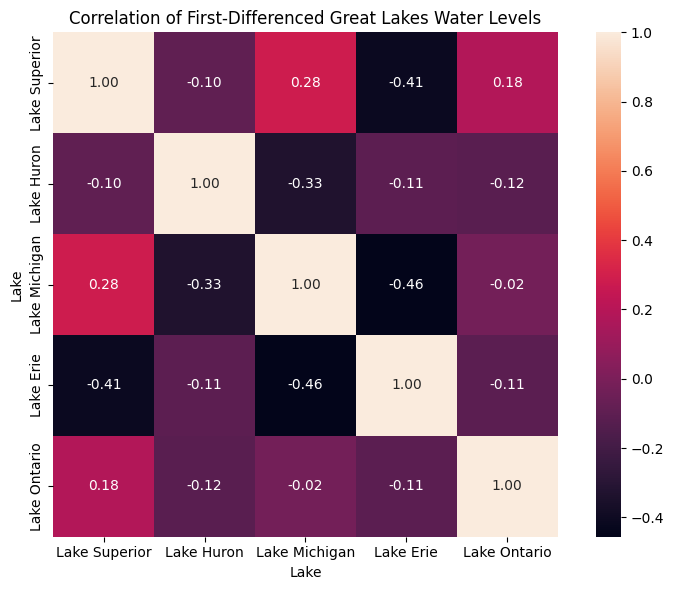

In [9]:
# Examine correlations among the differenced Great Lakes series used in VAR/VARX

great_lakes_diff_corr = (
    great_lakes_diff
    .corr()
)

display(
    great_lakes_diff_corr
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    great_lakes_diff_corr,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title(
    "Correlation of First-Differenced Great Lakes Water Levels"
)

plt.tight_layout()
plt.show()

Correlations among the first-differenced Great Lakes series were examined before VAR estimation to assess potential redundancy among the endogenous variables.

#### Final Model Refit and Test Forecasting

After selecting the model specification using the validation period, the final VAR/VARX models were refitted using all observations available before the independent test period.

The final evaluation period consisted of daily observations from 2022 to 2025, which were not used during model selection or parameter tuning.

In [10]:
# Refit the selected VAR model on the full pre-test period

final_var_model = VAR(
    var_full_pretest_train
)

final_var_fit = (
    final_var_model.fit(
        maxlags=
            best_var_lag,
        ic=None,
        trend="c"
    )
)

print(
    "Final VAR lag:",
    best_var_lag
)

print(
    "Final VAR AIC:",
    final_var_fit.aic
)

print(
    "Final VAR BIC:",
    final_var_fit.bic
)

Final VAR lag: 28
Final VAR AIC: -22.77471113869935
Final VAR BIC: -21.966271203051594


In [11]:
# Generate the final VAR forecast

final_var_diff_forecast = (
    final_var_fit.forecast(
        y=
            var_full_pretest_train
            .values[
                -best_var_lag:
            ],
        steps=
            len(var_final_test)
    )
)

final_var_diff_forecast = (
    pd.DataFrame(
        final_var_diff_forecast,
        index=
            var_final_test.index,
        columns=
            great_lakes
    )
)

final_var_start_level = (
    great_lakes_levels
    .loc[:"2021-12-31"]
    .iloc[-1]
)

final_var_level_forecast = (
    final_var_diff_forecast
    .cumsum()
    .add(
        final_var_start_level,
        axis="columns"
    )
)

final_var_actual_levels = (
    primary_lake_level_wide.loc[
        final_var_level_forecast.index,
        great_lakes
    ]
)

print(
    "Final VAR forecast shape:",
    final_var_level_forecast.shape
)

Final VAR forecast shape: (1461, 5)


In [12]:
# Evaluate final VAR performance for each Great Lake

var_final_metrics = []

for lake_name in great_lakes:

    metrics = (
        calculate_forecast_metrics(
            actual=
                final_var_actual_levels[
                    lake_name
                ],
            predicted=
                final_var_level_forecast[
                    lake_name
                ]
        )
    )

    observed_sd = (
        final_var_actual_levels[
            lake_name
        ]
        .std()
    )

    var_final_metrics.append({
        "Lake":
            lake_name,
        "Model":
            "Great Lakes VAR",
        "VAR Lag":
            best_var_lag,
        "RMSE":
            metrics["RMSE"],
        "MAE":
            metrics["MAE"],
        "R2":
            metrics["R2"],
        "NRMSE":
            metrics["RMSE"]
            / observed_sd,
        "N_test":
            metrics["N_test"]
    })

var_final_summary = pd.DataFrame(
    var_final_metrics
)

display(
    var_final_summary
)

,Lake,Model,VAR Lag,RMSE,MAE,R2,NRMSE,N_test
0,Lake Superior,Great Lakes VAR,28,0.925008,0.784330,-1.352488,1.533246,1430
1,Lake Huron,Great Lakes VAR,28,1.005580,0.780294,-1.437335,1.560662,1461
2,Lake Michigan,Great Lakes VAR,28,1.068493,0.825357,-1.447100,1.563785,1461
3,Lake Erie,Great Lakes VAR,28,1.046072,0.817298,-1.370537,1.539128,1461
4,Lake Ontario,Great Lakes VAR,28,0.929121,0.767865,-0.157716,1.075596,1431


#### VARX Validation Comparison

On the 2019–2021 validation period, VARX reduced the mean normalised forecasting error relative to VAR, although the magnitude and direction of improvement varied among the five Great Lakes. Final conclusions are based on the independent 2022–2025 test period.

## VARX

VAR(28) + contemporaneous PRCP/TMEAN

VARX predictors were constructed from the locked primary meteorological series. Retained internal PRCP gaps were linearly completed only to obtain the complete exogenous matrix required for model estimation; TMEAN was already complete for the five Great Lakes.

In [13]:
# Build lake-specific contemporaneous climate predictors
# from the locked primary dataset

great_lakes_climate_parts = []


for lake_name in great_lakes:

    lake_climate = (
        primary_water_climate[
            primary_water_climate["Lake"]
            == lake_name
        ][
            [
                "Date",
                "PRCP",
                "TMEAN"
            ]
        ]
        .copy()
    )

    lake_climate["Date"] = pd.to_datetime(
        lake_climate["Date"]
    )

    lake_climate = (
        lake_climate
        .set_index("Date")
        .sort_index()
        .reindex(
            great_lakes_levels.index
        )
    )

    lake_climate = (
        lake_climate.rename(
            columns={
                "PRCP":
                    f"{lake_name}_PRCP",
                "TMEAN":
                    f"{lake_name}_TMEAN"
            }
        )
    )

    great_lakes_climate_parts.append(
        lake_climate
    )


great_lakes_exog_raw = pd.concat(
    great_lakes_climate_parts,
    axis=1
)


print(
    "Missing climate predictors before "
    "VARX-specific completion:"
)

display(
    great_lakes_exog_raw
    .isna()
    .sum()
)

Missing climate predictors before VARX-specific completion:


Lake Superior_PRCP     0
Lake Superior_TMEAN    0
Lake Huron_PRCP        9
Lake Huron_TMEAN       0
Lake Michigan_PRCP     0
Lake Michigan_TMEAN    0
Lake Erie_PRCP         0
Lake Erie_TMEAN        0
Lake Ontario_PRCP      0
Lake Ontario_TMEAN     0
dtype: int64

In [14]:
# VARX requires complete exogenous predictors.
# In the locked primary Great Lakes data,
# TMEAN is complete while retained PRCP gaps
# are completed only for VARX modelling.

great_lakes_exog = (
    great_lakes_exog_raw
    .copy()
)


prcp_columns = [
    column
    for column in great_lakes_exog.columns
    if column.endswith("_PRCP")
]


great_lakes_exog[
    prcp_columns
] = (
    great_lakes_exog[
        prcp_columns
    ]
    .interpolate(
        method="time",
        limit_area="inside"
    )
)


if (
    great_lakes_exog
    .isna()
    .sum()
    .sum()
    != 0
):
    raise ValueError(
        "Missing VARX climate predictors remain "
        "after model-specific PRCP completion."
    )


print(
    "Climate predictor shape:",
    great_lakes_exog.shape
)

print(
    "Number of predictors:",
    great_lakes_exog.shape[1]
)

print(
    "Missing climate predictors after "
    "VARX-specific completion:"
)

display(
    great_lakes_exog
    .isna()
    .sum()
)

display(
    great_lakes_exog.head()
)

Climate predictor shape: (7305, 10)
Number of predictors: 10
Missing climate predictors after VARX-specific completion:


Lake Superior_PRCP     0
Lake Superior_TMEAN    0
Lake Huron_PRCP        0
Lake Huron_TMEAN       0
Lake Michigan_PRCP     0
Lake Michigan_TMEAN    0
Lake Erie_PRCP         0
Lake Erie_TMEAN        0
Lake Ontario_PRCP      0
Lake Ontario_TMEAN     0
dtype: int64

,Lake Superior_PRCP,Lake Superior_TMEAN,Lake Huron_PRCP,Lake Huron_TMEAN,Lake Michigan_PRCP,Lake Michigan_TMEAN,Lake Erie_PRCP,Lake Erie_TMEAN,Lake Ontario_PRCP,Lake Ontario_TMEAN
Date,,,,,,,,,,
2006-01-01,0.3,-5.85,0.3,-1.65,8.4,1.95,0.0,1.10,0.3,0.25
2006-01-02,2.5,-1.10,0.0,-1.65,16.5,4.15,4.6,2.50,2.0,2.20
2006-01-03,0.0,0.30,0.0,1.10,0.0,3.85,0.0,3.05,0.3,3.05
2006-01-04,0.0,-1.35,6.1,1.70,0.5,3.90,3.8,4.70,1.8,2.75
2006-01-05,0.0,-3.60,0.3,-3.35,0.0,0.55,6.9,2.50,1.5,2.80


PRCP is retained missing in the primary analysis, but completed only for VARX modelling because the exogenous matrix must be complete.

In [15]:
# Align climate predictors with the VAR modelling periods

varx_parameter_train_exog = (
    great_lakes_exog.loc[
        var_parameter_train.index
    ]
    .copy()
)

varx_validation_exog = (
    great_lakes_exog.loc[
        var_validation.index
    ]
    .copy()
)

print(
    "VARX parameter-training exog:",
    varx_parameter_train_exog.shape
)

print(
    "VARX validation exog:",
    varx_validation_exog.shape
)

print(
    "Training missing values:",
    varx_parameter_train_exog
    .isna()
    .sum()
    .sum()
)

print(
    "Validation missing values:",
    varx_validation_exog
    .isna()
    .sum()
    .sum()
)

VARX parameter-training exog: (4747, 10)
VARX validation exog: (1096, 10)
Training missing values: 0
Validation missing values: 0


In [16]:
# Check VARX endogenous and exogenous alignment

print(
    "Parameter-training endogenous:",
    var_parameter_train.shape
)

print(
    "Parameter-training exogenous:",
    varx_parameter_train_exog.shape
)

print(
    "Validation endogenous:",
    var_validation.shape
)

print(
    "Validation exogenous:",
    varx_validation_exog.shape
)


print(
    "Parameter-training dates aligned:",
    var_parameter_train.index.equals(
        varx_parameter_train_exog.index
    )
)

print(
    "Validation dates aligned:",
    var_validation.index.equals(
        varx_validation_exog.index
    )
)

Parameter-training endogenous: (4747, 5)
Parameter-training exogenous: (4747, 10)
Validation endogenous: (1096, 5)
Validation exogenous: (1096, 10)
Parameter-training dates aligned: True
Validation dates aligned: True


In [17]:
# Fit VARX using the selected VAR lag

varx_validation_model = VAR(
    endog=
        var_parameter_train,
    exog=
        varx_parameter_train_exog
)

varx_validation_fit = (
    varx_validation_model.fit(
        maxlags=
            best_var_lag,
        ic=None,
        trend="c"
    )
)

print(
    "VARX lag:",
    best_var_lag
)

print(
    "VARX AIC:",
    varx_validation_fit.aic
)

print(
    "VARX BIC:",
    varx_validation_fit.bic
)

VARX lag: 28
VARX AIC: -23.015215921152656
VARX BIC: -21.981774322349217


In [18]:
# Forecast the validation period with VARX

varx_validation_diff_forecast = (
    varx_validation_fit.forecast(
        y=
            var_parameter_train
            .values[
                -best_var_lag:
            ],
        steps=
            len(var_validation),
        exog_future=
            varx_validation_exog.values
    )
)

varx_validation_diff_forecast = (
    pd.DataFrame(
        varx_validation_diff_forecast,
        index=
            var_validation.index,
        columns=
            great_lakes
    )
)

varx_validation_start_level = (
    great_lakes_levels
    .loc[:"2018-12-31"]
    .iloc[-1]
)

varx_validation_level_forecast = (
    varx_validation_diff_forecast
    .cumsum()
    .add(
        varx_validation_start_level,
        axis="columns"
    )
)

varx_validation_actual_levels = (
    primary_lake_level_wide.loc[
        varx_validation_level_forecast.index,
        great_lakes
    ]
)

print(
    "VARX validation forecast shape:",
    varx_validation_level_forecast.shape
)

VARX validation forecast shape: (1096, 5)


In [19]:
# Evaluate VARX validation performance

varx_validation_metrics = []

for lake_name in great_lakes:

    metrics = (
        calculate_forecast_metrics(
            actual=
                varx_validation_actual_levels[
                    lake_name
                ],
            predicted=
                varx_validation_level_forecast[
                    lake_name
                ]
        )
    )

    observed_sd = (
        varx_validation_actual_levels[
            lake_name
        ]
        .std()
    )

    varx_validation_metrics.append({
        "Lake":
            lake_name,
        "Model":
            "VARX",
        "VAR Lag":
            best_var_lag,
        "RMSE":
            metrics["RMSE"],
        "MAE":
            metrics["MAE"],
        "R2":
            metrics["R2"],
        "NRMSE":
            metrics["RMSE"]
            / observed_sd,
        "N_validation":
            metrics["N_test"]
    })


varx_validation_summary = (
    pd.DataFrame(
        varx_validation_metrics
    )
)

display(
    varx_validation_summary
)

,Lake,Model,VAR Lag,RMSE,MAE,R2,NRMSE,N_validation
0,Lake Superior,VARX,28,0.332996,0.274975,0.576250,0.650664,1096
1,Lake Huron,VARX,28,0.694810,0.614900,0.027591,0.985645,1066
2,Lake Michigan,VARX,28,0.811686,0.712997,-0.298843,1.139148,1096
3,Lake Erie,VARX,28,0.722404,0.594052,-0.232857,1.109834,1096
4,Lake Ontario,VARX,28,1.616132,1.112428,-1.003169,1.414688,1096


In [20]:
# Evaluate the selected VAR(28) on the same validation period

selected_var_model = VAR(
    var_parameter_train
)

selected_var_fit = (
    selected_var_model.fit(
        maxlags=
            best_var_lag,
        ic=None,
        trend="c"
    )
)

selected_var_validation_diff = (
    selected_var_fit.forecast(
        y=
            var_parameter_train
            .values[
                -best_var_lag:
            ],
        steps=
            len(var_validation)
    )
)

selected_var_validation_diff = (
    pd.DataFrame(
        selected_var_validation_diff,
        index=
            var_validation.index,
        columns=
            great_lakes
    )
)

selected_var_validation_level = (
    selected_var_validation_diff
    .cumsum()
    .add(
        varx_validation_start_level,
        axis="columns"
    )
)


var_validation_metrics = []

for lake_name in great_lakes:

    metrics = (
        calculate_forecast_metrics(
            actual=
                varx_validation_actual_levels[
                    lake_name
                ],
            predicted=
                selected_var_validation_level[
                    lake_name
                ]
        )
    )

    observed_sd = (
        varx_validation_actual_levels[
            lake_name
        ]
        .std()
    )

    var_validation_metrics.append({
        "Lake":
            lake_name,
        "VAR RMSE":
            metrics["RMSE"],
        "VAR MAE":
            metrics["MAE"],
        "VAR R2":
            metrics["R2"],
        "VAR NRMSE":
            metrics["RMSE"]
            / observed_sd
    })


selected_var_validation_summary = (
    pd.DataFrame(
        var_validation_metrics
    )
)

In [21]:
# Compare VAR and VARX validation performance

var_vs_varx_validation = (
    selected_var_validation_summary
    .merge(
        varx_validation_summary[
            [
                "Lake",
                "RMSE",
                "MAE",
                "R2",
                "NRMSE"
            ]
        ],
        on="Lake",
        how="left"
    )
    .rename(
        columns={
            "RMSE":
                "VARX RMSE",
            "MAE":
                "VARX MAE",
            "R2":
                "VARX R2",
            "NRMSE":
                "VARX NRMSE"
        }
    )
)


var_vs_varx_validation[
    "VARX RMSE Improvement (%)"
] = (
    (
        var_vs_varx_validation[
            "VAR RMSE"
        ]
        -
        var_vs_varx_validation[
            "VARX RMSE"
        ]
    )
    /
    var_vs_varx_validation[
        "VAR RMSE"
    ]
    * 100
)


display(
    var_vs_varx_validation
)


print(
    "Mean VAR NRMSE:",
    round(
        var_vs_varx_validation[
            "VAR NRMSE"
        ].mean(),
        4
    )
)

print(
    "Mean VARX NRMSE:",
    round(
        var_vs_varx_validation[
            "VARX NRMSE"
        ].mean(),
        4
    )
)

print(
    "Mean VARX RMSE improvement (%):",
    round(
        var_vs_varx_validation[
            "VARX RMSE Improvement (%)"
        ].mean(),
        2
    )
)

,Lake,VAR RMSE,VAR MAE,VAR R2,VAR NRMSE,VARX RMSE,VARX MAE,VARX R2,VARX NRMSE,VARX RMSE Improvement (%)
0,Lake Superior,0.586192,0.482474,-0.313141,1.145401,0.332996,0.274975,0.576250,0.650664,43.193375
1,Lake Huron,1.007520,0.827873,-1.044677,1.429251,0.694810,0.614900,0.027591,0.985645,31.037649
2,Lake Michigan,0.979116,0.804907,-0.889944,1.374125,0.811686,0.712997,-0.298843,1.139148,17.100125
3,Lake Erie,0.700067,0.580920,-0.157797,1.075519,0.722404,0.594052,-0.232857,1.109834,-3.190611
4,Lake Ontario,1.169217,0.874646,-0.048466,1.023479,1.616132,1.112428,-1.003169,1.414688,-38.223427


Mean VAR NRMSE: 1.2096
Mean VARX NRMSE: 1.06
Mean VARX RMSE improvement (%): 9.98


## Final multivariate forecast evaluation

In [22]:
# Prepare exogenous climate data for final VARX evaluation

varx_full_pretest_exog = (
    great_lakes_exog.loc[
        var_full_pretest_train.index
    ]
    .copy()
)

varx_final_test_exog = (
    great_lakes_exog.loc[
        var_final_test.index
    ]
    .copy()
)

print(
    "Full pre-test exog shape:",
    varx_full_pretest_exog.shape
)

print(
    "Final-test exog shape:",
    varx_final_test_exog.shape
)

print(
    "Full pre-test missing values:",
    varx_full_pretest_exog
    .isna()
    .sum()
    .sum()
)

print(
    "Final-test missing values:",
    varx_final_test_exog
    .isna()
    .sum()
    .sum()
)

Full pre-test exog shape: (5843, 10)
Final-test exog shape: (1461, 10)
Full pre-test missing values: 0
Final-test missing values: 0


In [23]:
# Refit the locked VARX specification on the full pre-test period

final_varx_model = VAR(
    endog=
        var_full_pretest_train,
    exog=
        varx_full_pretest_exog
)

final_varx_fit = (
    final_varx_model.fit(
        maxlags=
            best_var_lag,
        ic=None,
        trend="c"
    )
)

print(
    "Final VARX lag:",
    best_var_lag
)

print(
    "Final VARX AIC:",
    final_varx_fit.aic
)

print(
    "Final VARX BIC:",
    final_varx_fit.bic
)

Final VARX lag: 28
Final VARX AIC: -23.03138155407109
Final VARX BIC: -22.165605452774557


In [24]:
# Generate the final VARX forecast for 2022-2025

final_varx_diff_forecast = (
    final_varx_fit.forecast(
        y=
            var_full_pretest_train
            .values[
                -best_var_lag:
            ],
        steps=
            len(var_final_test),
        exog_future=
            varx_final_test_exog.values
    )
)

final_varx_diff_forecast = (
    pd.DataFrame(
        final_varx_diff_forecast,
        index=
            var_final_test.index,
        columns=
            great_lakes
    )
)

print(
    "Final VARX differenced forecast shape:",
    final_varx_diff_forecast.shape
)

Final VARX differenced forecast shape: (1461, 5)


In [25]:
# Reconstruct predicted water levels

final_varx_start_level = (
    great_lakes_levels
    .loc[:"2021-12-31"]
    .iloc[-1]
)

final_varx_level_forecast = (
    final_varx_diff_forecast
    .cumsum()
    .add(
        final_varx_start_level,
        axis="columns"
    )
)

final_varx_actual_levels = (
    primary_lake_level_wide.loc[
        final_varx_level_forecast.index,
        great_lakes
    ]
    .copy()
)

print(
    "Final VARX level forecast shape:",
    final_varx_level_forecast.shape
)

print(
    "Final VARX actual level shape:",
    final_varx_actual_levels.shape
)

Final VARX level forecast shape: (1461, 5)
Final VARX actual level shape: (1461, 5)


In [26]:
# Evaluate final VARX performance for each Great Lake

varx_final_metrics = []


for lake_name in great_lakes:

    metrics = calculate_forecast_metrics(
        actual=
            final_varx_actual_levels[
                lake_name
            ],
        predicted=
            final_varx_level_forecast[
                lake_name
            ]
    )


    observed_sd = (
        final_varx_actual_levels[
            lake_name
        ]
        .std()
    )


    varx_final_metrics.append({
        "Lake":
            lake_name,
        "Model":
            "Great Lakes VARX",
        "VAR Lag":
            best_var_lag,
        "RMSE":
            metrics["RMSE"],
        "MAE":
            metrics["MAE"],
        "R2":
            metrics["R2"],
        "NRMSE":
            metrics["RMSE"]
            / observed_sd,
        "N_test":
            metrics["N_test"]
    })


varx_final_summary = (
    pd.DataFrame(
        varx_final_metrics
    )
)


display(
    varx_final_summary
)

,Lake,Model,VAR Lag,RMSE,MAE,R2,NRMSE,N_test
0,Lake Superior,Great Lakes VARX,28,2.276077,2.175226,-13.243293,3.772709,1430
1,Lake Huron,Great Lakes VARX,28,1.091918,0.994736,-1.873837,1.694659,1461
2,Lake Michigan,Great Lakes VARX,28,0.810252,0.688214,-0.407178,1.185839,1461
3,Lake Erie,Great Lakes VARX,28,0.513488,0.396412,0.428805,0.755516,1461
4,Lake Ontario,Great Lakes VARX,28,1.220130,0.928705,-0.996502,1.412483,1431


In [27]:
# Compare final VAR and VARX performance

var_vs_varx_final = (
    var_final_summary[
        [
            "Lake",
            "RMSE",
            "MAE",
            "R2",
            "NRMSE",
            "N_test"
        ]
    ]
    .rename(
        columns={
            "RMSE":
                "VAR RMSE",
            "MAE":
                "VAR MAE",
            "R2":
                "VAR R2",
            "NRMSE":
                "VAR NRMSE",
            "N_test":
                "VAR N_test"
        }
    )
    .merge(
        varx_final_summary[
            [
                "Lake",
                "RMSE",
                "MAE",
                "R2",
                "NRMSE",
                "N_test"
            ]
        ]
        .rename(
            columns={
                "RMSE":
                    "VARX RMSE",
                "MAE":
                    "VARX MAE",
                "R2":
                    "VARX R2",
                "NRMSE":
                    "VARX NRMSE",
                "N_test":
                    "VARX N_test"
            }
        ),
        on="Lake",
        how="left",
        validate="one_to_one"
    )
)


# Calculate RMSE improvement from VAR to VARX
# Positive values indicate improvement from VARX

var_vs_varx_final[
    "VARX RMSE Improvement (%)"
] = (
    (
        var_vs_varx_final[
            "VAR RMSE"
        ]
        -
        var_vs_varx_final[
            "VARX RMSE"
        ]
    )
    /
    var_vs_varx_final[
        "VAR RMSE"
    ]
    * 100
)


# Verify that VAR and VARX were evaluated
# on the same observed test dates

var_vs_varx_final[
    "Evaluation N Match"
] = (
    var_vs_varx_final[
        "VAR N_test"
    ]
    ==
    var_vs_varx_final[
        "VARX N_test"
    ]
)


if not var_vs_varx_final[
    "Evaluation N Match"
].all():

    raise ValueError(
        "VAR and VARX were not evaluated "
        "on the same number of observed test dates."
    )


# Display final comparison

display(
    var_vs_varx_final
)


# Summarise overall final-test performance

mean_var_nrmse = (
    var_vs_varx_final[
        "VAR NRMSE"
    ]
    .mean()
)


mean_varx_nrmse = (
    var_vs_varx_final[
        "VARX NRMSE"
    ]
    .mean()
)


mean_varx_rmse_improvement = (
    var_vs_varx_final[
        "VARX RMSE Improvement (%)"
    ]
    .mean()
)


print(
    "Mean final VAR NRMSE:",
    round(
        mean_var_nrmse,
        4
    )
)


print(
    "Mean final VARX NRMSE:",
    round(
        mean_varx_nrmse,
        4
    )
)


print(
    "Mean final VARX RMSE improvement (%):",
    round(
        mean_varx_rmse_improvement,
        2
    )
)


# Export final VAR / VARX comparison

var_vs_varx_final.to_csv(
    forecast_output_dir
    / "var_vs_varx_final.csv",
    index=False
)


print(
    "VAR / VARX final comparison exported to:",
    forecast_output_dir
)

,Lake,VAR RMSE,VAR MAE,VAR R2,VAR NRMSE,VAR N_test,VARX RMSE,VARX MAE,VARX R2,VARX NRMSE,VARX N_test,VARX RMSE Improvement (%),Evaluation N Match
0,Lake Superior,0.925008,0.784330,-1.352488,1.533246,1430,2.276077,2.175226,-13.243293,3.772709,1430,-146.060260,True
1,Lake Huron,1.005580,0.780294,-1.437335,1.560662,1461,1.091918,0.994736,-1.873837,1.694659,1461,-8.585916,True
2,Lake Michigan,1.068493,0.825357,-1.447100,1.563785,1461,0.810252,0.688214,-0.407178,1.185839,1461,24.168660,True
3,Lake Erie,1.046072,0.817298,-1.370537,1.539128,1461,0.513488,0.396412,0.428805,0.755516,1461,50.912740,True
4,Lake Ontario,0.929121,0.767865,-0.157716,1.075596,1431,1.220130,0.928705,-0.996502,1.412483,1431,-31.320914,True


Mean final VAR NRMSE: 1.4545
Mean final VARX NRMSE: 1.7642
Mean final VARX RMSE improvement (%): -22.18
VAR / VARX final comparison exported to: D:\Postgraduate\DATA72000 Data Science Extended Research Project\ERP Final\outputs\forecasting_results


In [29]:
final_var_level_forecast.to_csv(
    forecast_output_dir
    / "VAR_final_forecast.csv",
    index=True,
    index_label="Date"
)


final_varx_level_forecast.to_csv(
    forecast_output_dir
    / "VARX_final_forecast.csv",
    index=True,
    index_label="Date"
)


var_metrics_df = pd.DataFrame(
    var_final_metrics
)

varx_metrics_df = pd.DataFrame(
    varx_final_metrics
)


var_metrics_df["Model"] = "VAR"
varx_metrics_df["Model"] = "VARX"


var_varx_metrics = pd.concat(
    [
        var_metrics_df,
        varx_metrics_df
    ],
    ignore_index=True
)


var_varx_metrics.to_csv(
    forecast_output_dir
    / "VAR_VARX_final_metrics.csv",
    index=False
)

var_validation_summary.to_csv(
    forecast_output_dir / "var_lag_validation_summary.csv",
    index=False
)


print(
    "VAR / VARX forecasting outputs saved to:",
    forecast_output_dir
)

VAR / VARX forecasting outputs saved to: D:\Postgraduate\DATA72000 Data Science Extended Research Project\ERP Final\outputs\forecasting_results
